In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind

import util_data
import util_nn

In [2]:
skip_nsample = 150
data_nsample = 10_000 - skip_nsample
data = util_data.read_datafile('../../data/mujoco/hopper_all_0', data_nsample)
print(f'read data shape: {data.shape}')

state_ndim = 11
action_ndim = 3
states, actions = torch.split(data, [state_ndim, action_ndim], dim=-1)
print(f'read states shape: {states.shape}')
print(f'read actions shape: {actions.shape}')

state_mean = states.mean()
state_std = states.std() + 1e-6

action_mean = actions.mean()
action_std = actions.std() + 1e-6

states = (states - state_mean) / state_std
actions = (actions - action_mean) / action_std

train_states = states[0, :-1]
train_next_states = states[0, 1:]
train_actions = actions[0, :-1]
print(f'states for training shape: {train_states.shape}')
print(f'next states for training shape: {train_next_states.shape}')
print(f'action for training shape: {train_actions.shape}')

dataset = torch.utils.data.TensorDataset(train_states, train_actions, train_next_states)
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([1, 10000, 14])
read states shape: torch.Size([1, 9850, 11])
read actions shape: torch.Size([1, 9850, 3])
states for training shape: torch.Size([9849, 11])
next states for training shape: torch.Size([9849, 11])
action for training shape: torch.Size([9849, 3])


In [3]:
class dynamics(torch.nn.Module):
    def __init__(self, state_dim=11, action_dim=3, hidden_dim=256):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(state_dim + action_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, state_dim)  # predicts delta state
        )

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        delta = self.net(x)
        s_next_pred = s + delta
        return s_next_pred

In [4]:
model = dynamics()

load_pretrained = True
if load_pretrained:
    # --! load trained weights into the model
    model_path = '../../models/mujoco/hopper_monolith_checkpoint.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))

else:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = torch.nn.MSELoss()

    num_epochs = 1_000

    for epoch in range(num_epochs):
        total_loss = 0.0

        for s, a, s_next in loader:
            pred = model(s, a)
            loss = loss_fn(pred, s_next)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(loader):.6f}")

    torch.save(model.state_dict(), '../../models/mujoco/hopper_monolith_checkpoint.pth')

In [5]:
def rollout(model, s0, actions):
    s = s0
    traj = [s0]

    for a in actions:
        s = model(s, a)
        traj.append(s)

    return torch.stack(traj)

model.eval()
util_nn.freeze_module(model)

s0 = states[0, 0]
rollout_traj = rollout(model, s0, actions[0])
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([9851, 11])


In [6]:
def jacobian_wrt_state(model, s, a):
    s = s.clone().detach().requires_grad_(True)
    a = a.clone().detach()  # fixed

    def f_state_only(s_in):
        return model(s_in.unsqueeze(0), a.unsqueeze(0)).squeeze(0)

    J = torch.autograd.functional.jacobian(f_state_only, s)
    return J  # shape (11, 11)

def spectral_radius(J):
    eigvals = torch.linalg.eigvals(J)
    return eigvals.abs().max().item()

def singular_value(J):
    singular_vals = torch.linalg.svdvals(J)
    return singular_vals.max().item()

sigmas_max = []
spectral_radii = []
for s, a in zip(states[0], actions[0]):
    J = jacobian_wrt_state(model, s, a)
    rho = spectral_radius(J)
    sigma_max = singular_value(J)
    spectral_radii.append(rho)
    sigmas_max.append(sigma_max)

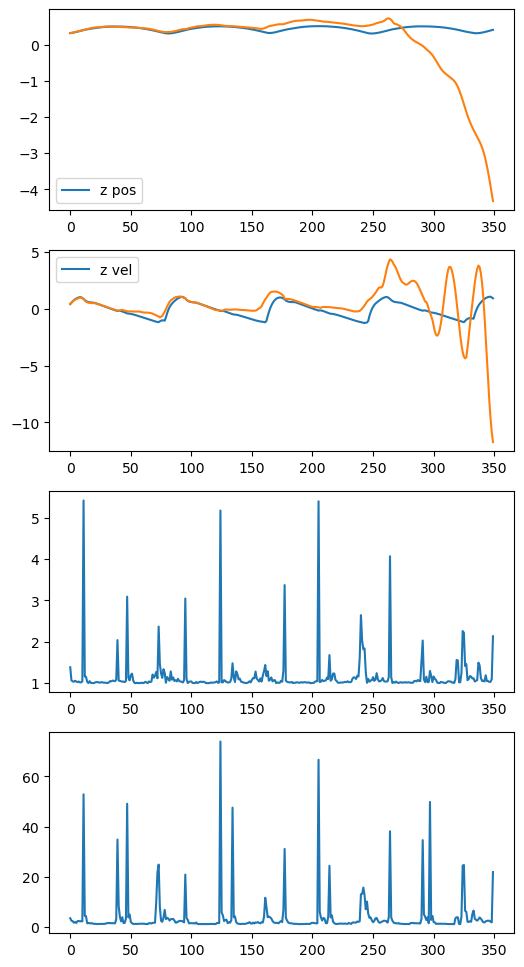

In [21]:
disp_end = 350
datasaved = False

with torch.no_grad():
    plt.figure(figsize=(6,12))

    plt.subplot(4,1,1)
    plt.plot(states[0, :disp_end, 0], label='z pos')
    plt.plot(rollout_traj[:disp_end, 0])
    plt.legend()

    plt.subplot(4,1,2)
    plt.plot(states[0, :disp_end, 6], label='z vel')
    plt.plot(rollout_traj[:disp_end, 6])
    plt.legend()

    plt.subplot(4,1,3)
    plt.plot(spectral_radii[:disp_end])

    plt.subplot(4,1,4)
    plt.plot(sigmas_max[:disp_end])

    plt.show()

    if datasaved:
        save_step = torch.arange(states.shape[1]).reshape(1, -1, 1)
        save_rollout_traj = torch.unsqueeze(rollout_traj, 0)
        save_radii = torch.tensor(spectral_radii).reshape(1, -1, 1)
        save_sigmas = torch.tensor(sigmas_max).reshape(1, -1, 1)
        savedata = np.concatenate([
            save_step[:1, :disp_end, :1],
            states[:1, :disp_end, :1], states[:1, :disp_end, [6]],
            save_rollout_traj[:1, :disp_end, :1], save_rollout_traj[:1, :disp_end, [6]],
            save_radii[:1, :disp_end, :1], save_sigmas[:1, :disp_end, :1]], axis=2)
        util_data.write_datafile(f'../../results/mujoco/hopper_monolith_rollout', savedata, delim=' ')
